# Fraud Detection System

## Project Objective

The goal of this project is to build an end-to-end fraud detection system
for financial transactions.

The project will cover:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Handling class imbalance
- Machine Learning models
- Deep Learning (MLP) model
- Model evaluation and comparison
- Probability and threshold tuning
- Model persistence
- FastAPI-based inference API
- Professional user interface
- Testing and Dockerization

## Dataset

This project uses the PaySim synthetic financial transaction dataset.

The target variable is `isFraud`, where:

- `0` = Legitimate transaction
- `1` = Fraudulent transaction

In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6362620, 11)


In [6]:
# Check the size of the dataset
print("Dataset Shape:")
print(df.shape)

# Check column names and data types
print("\nDataset Information:")
df.info()

# Check missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(6362620, 11)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [7]:
# Count legitimate and fraudulent transactions
fraud_counts = df["isFraud"].value_counts()

print("Transaction Class Distribution:")
print(fraud_counts)

# Calculate the percentage of each class
fraud_percentage = df["isFraud"].value_counts(normalize=True) * 100

print("\nTransaction Class Percentage:")
print(fraud_percentage.round(4))

# Calculate the fraud rate
fraud_rate = fraud_percentage[1]

print(f"\nFraud Rate: {fraud_rate:.4f}%")

Transaction Class Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Transaction Class Percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

Fraud Rate: 0.1291%


In [8]:
# Count transactions by transaction type
type_counts = df["type"].value_counts()

print("Transaction Count by Type:")
print(type_counts)

# Calculate fraud count for each transaction type
fraud_by_type = df.groupby("type")["isFraud"].sum()

print("\nFraud Count by Transaction Type:")
print(fraud_by_type)

# Calculate fraud rate within each transaction type
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nFraud Rate by Transaction Type (%):")
print(fraud_rate_by_type.round(4))

Transaction Count by Type:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud Count by Transaction Type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

Fraud Rate by Transaction Type (%):
type
TRANSFER    0.7688
CASH_OUT    0.1840
CASH_IN     0.0000
DEBIT       0.0000
PAYMENT     0.0000
Name: isFraud, dtype: float64


In [9]:
# Compare transaction amounts between legitimate and fraudulent transactions
amount_summary = df.groupby("isFraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

# Give the target labels meaningful names
amount_summary.index = ["Legitimate", "Fraudulent"]

print("Transaction Amount Summary:")
print(amount_summary.round(2))

Transaction Amount Summary:
              count        mean     median   min          max
Legitimate  6354407   178197.04   74684.72  0.01  92445516.64
Fraudulent     8213  1467967.30  441423.44  0.00  10000000.00


In [10]:
# Compare the average transaction amount for each transaction type
type_amount_summary = df.groupby(["type", "isFraud"])["amount"].agg(
    ["count", "mean", "median"]
)

print("Transaction Amount by Type and Fraud Status:")
print(type_amount_summary.round(2))

Transaction Amount by Type and Fraud Status:
                    count        mean     median
type     isFraud                                
CASH_IN  0        1399284   168920.24  143427.71
CASH_OUT 0        2233384   173917.16  146946.56
         1           4116  1455102.59  435516.90
DEBIT    0          41432     5483.67    3048.99
PAYMENT  0        2151495    13057.60    9482.19
TRANSFER 0         528812   906229.01  486521.91
         1           4097  1480891.67  445705.76


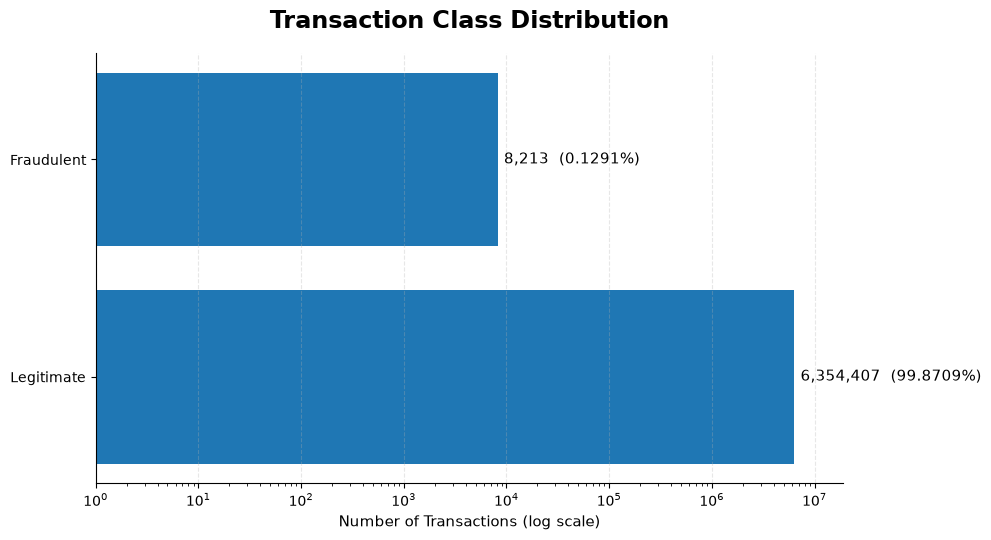

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count legitimate and fraudulent transactions
class_counts = df["isFraud"].value_counts().sort_index()

# Calculate percentage of each class
class_percentages = df["isFraud"].value_counts(normalize=True).sort_index() * 100

# Prepare readable labels
labels = ["Legitimate", "Fraudulent"]
counts = class_counts.values
percentages = class_percentages.values

# Create the figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Create a horizontal bar chart
bars = ax.barh(labels, counts)

# Use a logarithmic x-axis because the class sizes are highly imbalanced
ax.set_xscale("log")

# Add count and percentage labels
for bar, count, percentage in zip(bars, counts, percentages):
    ax.text(
        count * 1.15,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({percentage:.4f}%)",
        va="center",
        fontsize=11
    )

# Titles and labels
ax.set_title(
    "Transaction Class Distribution",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Number of Transactions (log scale)", fontsize=11)

# Keep the chart visually clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Give labels enough space
ax.set_xlim(left=1, right=class_counts.max() * 3)

plt.tight_layout()
plt.show()

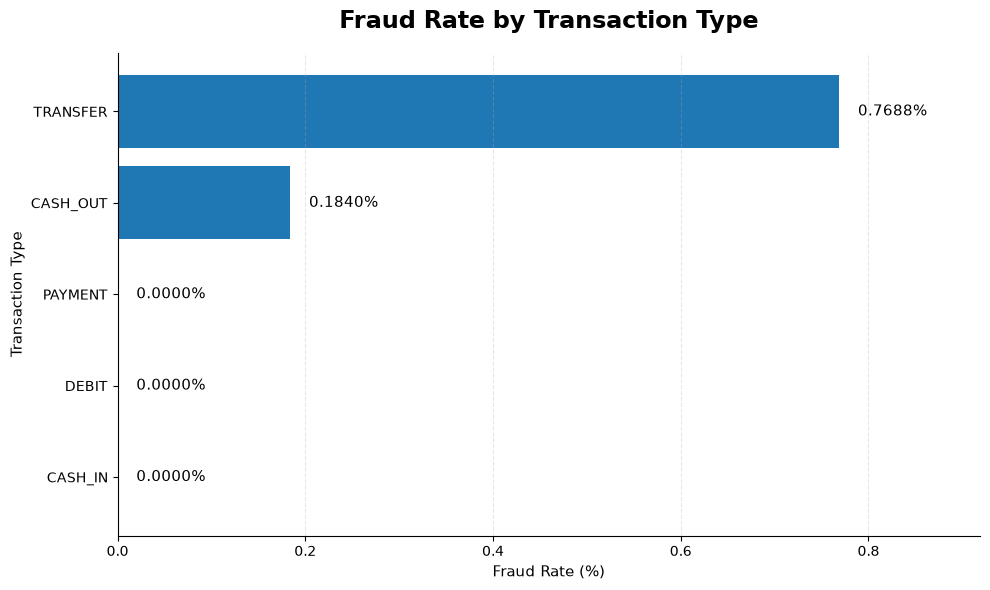

In [12]:
# Calculate fraud rate for each transaction type
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create a horizontal bar chart
bars = ax.barh(
    fraud_rate_by_type.index,
    fraud_rate_by_type.values
)

# Add percentage labels to each bar
for bar, rate in zip(bars, fraud_rate_by_type.values):
    ax.text(
        rate + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.4f}%",
        va="center",
        fontsize=11
    )

# Titles and labels
ax.set_title(
    "Fraud Rate by Transaction Type",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Fraud Rate (%)", fontsize=11)
ax.set_ylabel("Transaction Type", fontsize=11)

# Keep the chart clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Give labels enough space
ax.set_xlim(0, fraud_rate_by_type.max() + 0.15)

plt.tight_layout()
plt.show()

# Observation:
# Fraud is concentrated in TRANSFER and CASH_OUT transactions.
# TRANSFER has the highest fraud rate among the transaction types.

Dataset loaded successfully!
Dataset Shape: (6362620, 11)


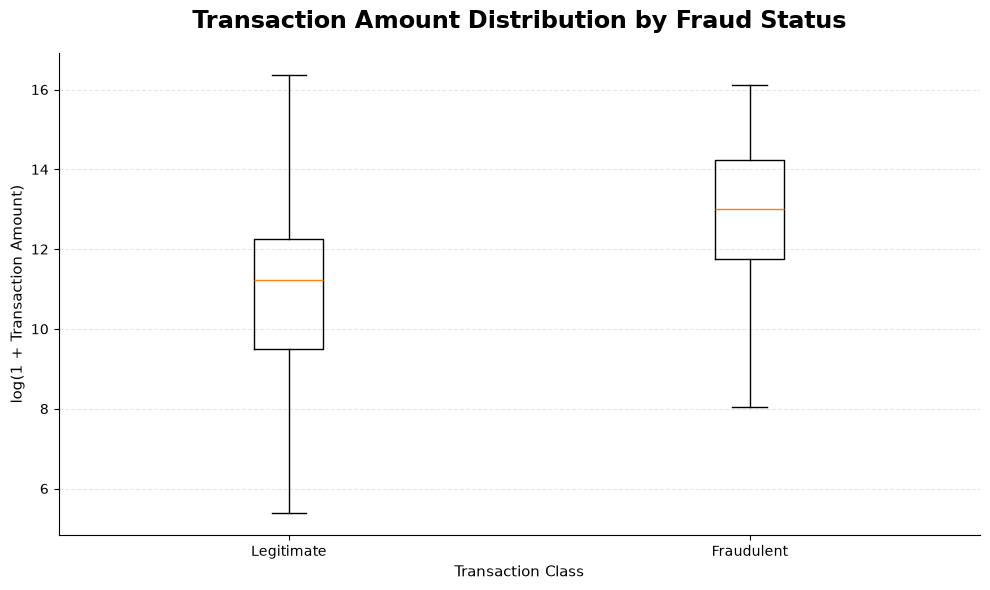

In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/raw/transactions.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

# Create a log-transformed amount for visualization
df["log_amount"] = np.log1p(df["amount"])

# Separate legitimate and fraudulent transactions
legitimate_amount = df.loc[df["isFraud"] == 0, "log_amount"]
fraudulent_amount = df.loc[df["isFraud"] == 1, "log_amount"]

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots to compare the two classes
ax.boxplot(
    [legitimate_amount, fraudulent_amount],
    tick_labels=["Legitimate", "Fraudulent"],
    showfliers=False
)

# Titles and labels
ax.set_title(
    "Transaction Amount Distribution by Fraud Status",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Transaction Class", fontsize=11)
ax.set_ylabel("log(1 + Transaction Amount)", fontsize=11)

# Keep the chart clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Observation:
# Fraudulent transactions tend to have a different amount distribution
# compared with legitimate transactions.
# Transaction amount can therefore provide useful predictive information,
# but it should be combined with other transaction features.

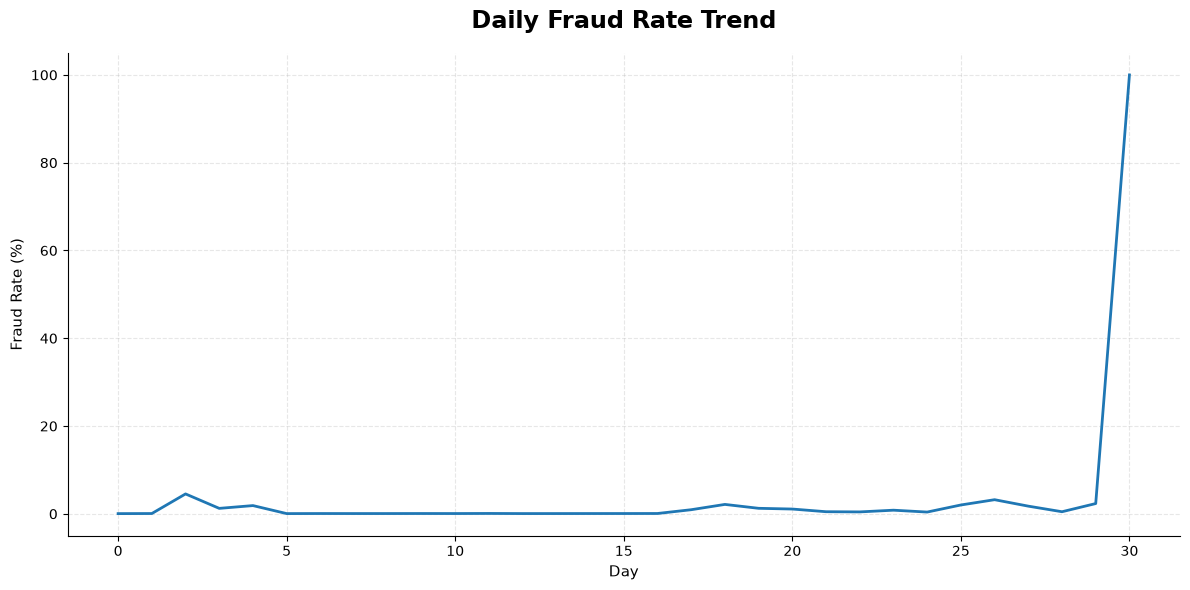

Top 10 Days by Fraud Rate:
day
30    100.0000
2       4.5340
26      3.2190
29      2.3398
18      2.1442
25      2.0154
4       1.8776
27      1.7491
19      1.2564
3       1.2418
dtype: float64


In [14]:
# Analyze fraud trends over time

import pandas as pd
import matplotlib.pyplot as plt

# Convert hourly steps into approximate days
df["day"] = df["step"] // 24

# Calculate total and fraudulent transactions per day
daily_transactions = df.groupby("day").size()

daily_fraud = df.groupby("day")["isFraud"].sum()

# Calculate daily fraud rate
daily_fraud_rate = (daily_fraud / daily_transactions) * 100

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    daily_fraud_rate.index,
    daily_fraud_rate.values,
    linewidth=2
)

ax.set_title(
    "Daily Fraud Rate Trend",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Day", fontsize=11)
ax.set_ylabel("Fraud Rate (%)", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Display days with the highest fraud rates
print("Top 10 Days by Fraud Rate:")
print(daily_fraud_rate.sort_values(ascending=False).head(10).round(4))

In [15]:
# Analyze balance inconsistencies in transactions

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Calculate balance difference for the origin account
df["origin_balance_error"] = (
    df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
)

# Calculate balance difference for the destination account
df["destination_balance_error"] = (
    df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
)

# Compare balance errors between legitimate and fraudulent transactions
balance_error_summary = df.groupby("isFraud")[
    ["origin_balance_error", "destination_balance_error"]
].agg(["mean", "median", "std"])

balance_error_summary.index = ["Legitimate", "Fraudulent"]

print("Balance Error Summary:")
display(balance_error_summary.round(2))

Balance Error Summary:


origin_balance_error                       \
                           mean    median        std   
Legitimate           -201338.56 -69049.31  606928.89   
Fraudulent            -10692.33      0.00  265146.13   

           destination_balance_error                       
                                mean   median         std  
Legitimate                  54692.23  3500.68   436002.63  
Fraudulent                 732509.30  2231.46  1867747.99

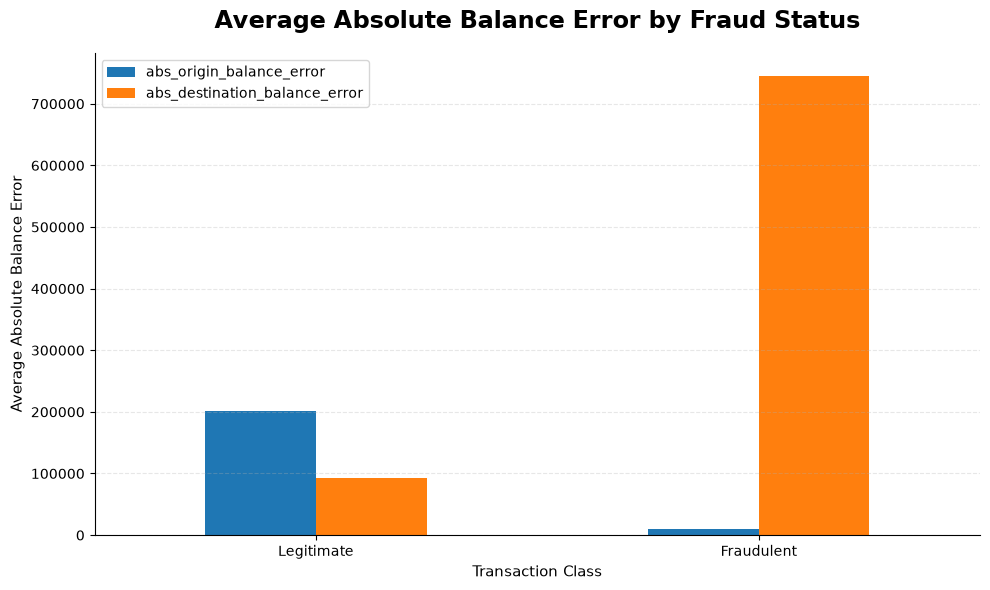

In [16]:
# Visualize average absolute balance errors by fraud status

df["abs_origin_balance_error"] = df["origin_balance_error"].abs()
df["abs_destination_balance_error"] = df["destination_balance_error"].abs()

absolute_error_summary = df.groupby("isFraud")[
    ["abs_origin_balance_error", "abs_destination_balance_error"]
].mean()

absolute_error_summary.index = ["Legitimate", "Fraudulent"]

ax = absolute_error_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Average Absolute Balance Error by Fraud Status",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Transaction Class", fontsize=11)
ax.set_ylabel("Average Absolute Balance Error", fontsize=11)

ax.set_xticklabels(
    ["Legitimate", "Fraudulent"],
    rotation=0
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Inspect feature uniqueness and data types

feature_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

display(feature_summary)

,Data Type,Unique Values,Missing Values
step,int64,743,0
type,str,5,0
amount,float64,5316900,0
nameOrig,str,6353307,0
oldbalanceOrg,float64,1845844,0
newbalanceOrig,float64,2682586,0
nameDest,str,2722362,0
oldbalanceDest,float64,3614697,0
newbalanceDest,float64,3555499,0
isFraud,int64,2,0


In [18]:
# Define target and feature columns

target_column = "isFraud"

columns_to_drop = [
    "isFraud",
    "nameOrig",
    "nameDest",
    "log_amount",
    "day",
    "origin_balance_error",
    "destination_balance_error",
    "abs_origin_balance_error",
    "abs_destination_balance_error"
]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_drop
]

print("Target Column:", target_column)

print("\nSelected Features:")
for feature in feature_columns:
    print("-", feature)

print("\nNumber of Selected Features:", len(feature_columns))

Target Column: isFraud

Selected Features:
- step
- type
- amount
- oldbalanceOrg
- newbalanceOrig
- oldbalanceDest
- newbalanceDest
- isFlaggedFraud

Number of Selected Features: 8


In [19]:
# Prepare features and target variable

# Target variable
y = df["isFraud"]

# Columns that should not be used directly for model training
columns_to_drop = [
    "isFraud",
    "nameOrig",
    "nameDest",
    "log_amount",
    "day",
    "origin_balance_error",
    "destination_balance_error",
    "abs_origin_balance_error",
    "abs_destination_balance_error"
]

# Input features
X = df.drop(columns=columns_to_drop)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Distribution:")
print(y.value_counts())

Feature Shape: (6362620, 8)
Target Shape: (6362620,)

Feature Columns:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']

Target Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [20]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(4))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(4))

Training Features Shape: (5090096, 8)
Testing Features Shape: (1272524, 8)

Training Target Distribution:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

Testing Target Distribution:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


In [21]:
# Identify numerical and categorical features

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['type']

Numerical Features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']


C:\Users\hp\AppData\Local\Temp\ipykernel_9528\3313951757.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [22]:
# Build the preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numerical features
numerical_transformer = StandardScaler()

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [23]:
# Fit the preprocessing pipeline on training data
# and transform both training and testing features

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (5090096, 12)
Testing data after preprocessing: (1272524, 12)


In [24]:
# Train a baseline Logistic Regression-style model
# using SGDClassifier for better scalability on large datasets

from sklearn.linear_model import SGDClassifier

baseline_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=20,
    random_state=42,
    n_jobs=-1
)

print("Training baseline model...")

baseline_model.fit(X_train_processed, y_train)

print("Baseline model trained successfully!")

Training baseline model...
Baseline model trained successfully!


c:\Users\hp\Desktop\AI_ML_Projects\fraud-detection-system\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [25]:
# Generate predictions on the test dataset

# Predict fraud probabilities
y_test_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

# Convert probabilities into class predictions using default threshold 0.5
y_test_pred = (y_test_proba >= 0.5).astype(int)

print("Predictions generated successfully!")

print("\nFirst 10 Fraud Probabilities:")
print(y_test_proba[:10])

print("\nFirst 10 Predicted Classes:")
print(y_test_pred[:10])

Predictions generated successfully!

First 10 Fraud Probabilities:
[0.22565427 0.00120237 0.00844301 0.24381246 0.42184124 0.53163289
 0.44860895 0.30145367 0.15293106 0.00154547]

First 10 Predicted Classes:
[0 0 0 0 0 1 0 0 0 0]


In [26]:
# Evaluate the baseline fraud detection model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print(cm)

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_test_proba)

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_test_proba)

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.92      0.96   1270881
  Fraudulent       0.01      0.93      0.03      1643

    accuracy                           0.92   1272524
   macro avg       0.51      0.92      0.49   1272524
weighted avg       1.00      0.92      0.96   1272524


Confusion Matrix:
[[1165869  105012]
 [    112    1531]]

ROC-AUC Score: 0.9814
PR-AUC Score: 0.5545


In [27]:
# Recreate and train the baseline model

from sklearn.linear_model import SGDClassifier

baseline_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=20,
    random_state=42,
    n_jobs=-1
)

print("Training baseline model again...")

baseline_model.fit(
    X_train_processed,
    y_train
)

print("Baseline model trained successfully!")

Training baseline model again...
Baseline model trained successfully!


c:\Users\hp\Desktop\AI_ML_Projects\fraud-detection-system\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [28]:
# Analyze model performance at different probability thresholds

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Generate fraud probabilities
y_test_proba = baseline_model.predict_proba(
    X_test_processed
)[:, 1]

# Define thresholds
thresholds = np.arange(0.05, 1.00, 0.05)

threshold_results = []

# Evaluate each threshold
for threshold in thresholds:

    predictions = (
        y_test_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert results into DataFrame
threshold_df = pd.DataFrame(threshold_results)

print("Threshold Evaluation Results:")
display(threshold_df.round(4))

Threshold Evaluation Results:


,Threshold,Precision,Recall,F1-Score
0,0.05,0.0031,1.0000,0.0061
1,0.10,0.0032,1.0000,0.0064
2,0.15,0.0034,0.9988,0.0068
3,0.20,0.0038,0.9970,0.0075
4,0.25,0.0043,0.9951,0.0086
5,0.30,0.0051,0.9848,0.0102
6,0.35,0.0063,0.9732,0.0125
7,0.40,0.0080,0.9617,0.0159
8,0.45,0.0106,0.9483,0.0210
9,0.50,0.0144,0.9318,0.0283


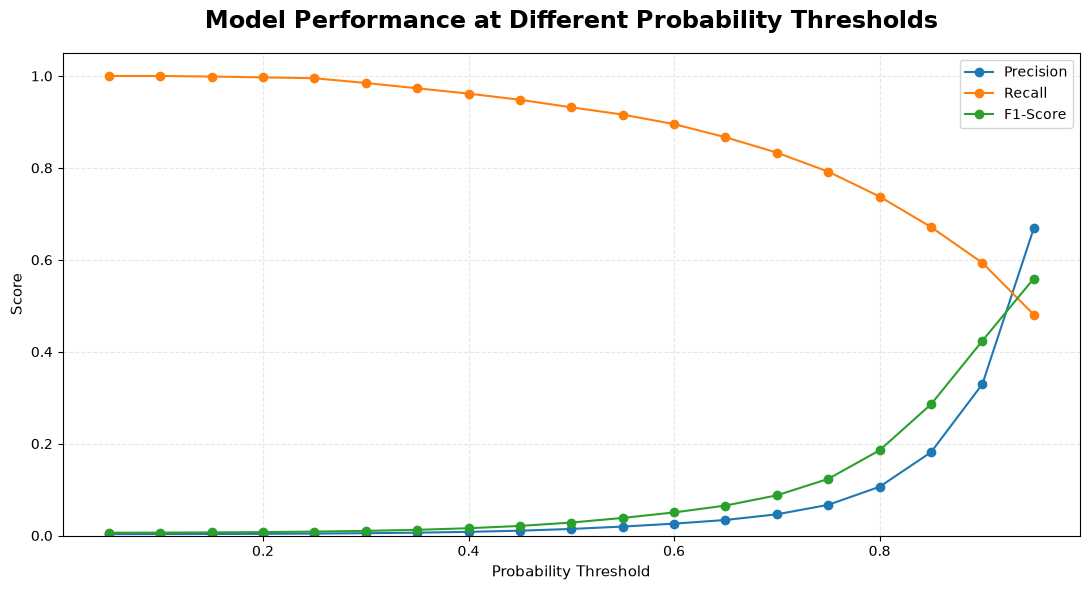

In [29]:
# Visualize precision, recall, and F1-score at different thresholds

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

ax.set_title(
    "Model Performance at Different Probability Thresholds",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Probability Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)

ax.set_ylim(0, 1.05)

ax.legend()
ax.grid(axis="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Identify the threshold with the highest F1-score

best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

print("Best Threshold Based on F1-Score:")

display(
    best_threshold_row.to_frame().T.round(4)
)

Best Threshold Based on F1-Score:


,Threshold,Precision,Recall,F1-Score
18,0.95,0.6684,0.4808,0.5593


In [31]:
# Store the selected threshold

best_threshold = float(
    best_threshold_row["Threshold"]
)

print(f"Selected Threshold: {best_threshold:.2f}")

Selected Threshold: 0.95


Confusion Matrix at Selected Threshold:
[[1270489     392]
 [    853     790]]

Classification Report at Selected Threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
  Fraudulent       0.67      0.48      0.56      1643

    accuracy                           1.00   1272524
   macro avg       0.83      0.74      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



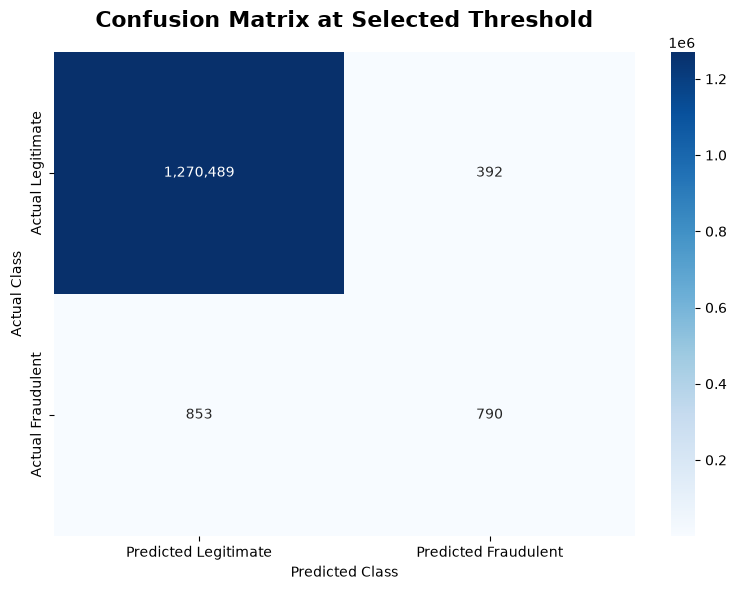

In [32]:
# Evaluate the model using the selected probability threshold

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Generate predictions using the selected threshold
y_test_pred_selected = (
    y_test_proba >= best_threshold
).astype(int)

# Calculate confusion matrix
cm_selected = confusion_matrix(
    y_test,
    y_test_pred_selected
)

print("Confusion Matrix at Selected Threshold:")
print(cm_selected)

print("\nClassification Report at Selected Threshold:")
print(
    classification_report(
        y_test,
        y_test_pred_selected,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_selected,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=["Predicted Legitimate", "Predicted Fraudulent"],
    yticklabels=["Actual Legitimate", "Actual Fraudulent"],
    ax=ax
)

ax.set_title(
    "Confusion Matrix at Selected Threshold",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

## Baseline Model Results

The baseline model used was `SGDClassifier` with:

- `loss="log_loss"`
- `class_weight="balanced"`
- `max_iter=20`
- Probability threshold selected using maximum F1-score

### Results

| Metric | Score |
|---|---:|
| ROC-AUC | 0.9814 |
| PR-AUC | 0.5545 |
| Fraud Precision at threshold 0.95 | 0.6684 |
| Fraud Recall at threshold 0.95 | 0.4808 |
| Fraud F1-score at threshold 0.95 | 0.5593 |

The model achieved strong ROC-AUC, but fraud detection remains challenging because the dataset is highly imbalanced.

The next step is to evaluate a nonlinear tree-based model.

In [33]:
# Train an XGBoost model for fraud detection

import xgboost as xgb

# Calculate class imbalance ratio
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost model...")

# Train the model
xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=25
)

print("XGBoost model trained successfully!")

Scale Pos Weight: 773.75
Training XGBoost model...
[0]	validation_0-aucpr:0.60932
[25]	validation_0-aucpr:0.90773
[50]	validation_0-aucpr:0.92554
[75]	validation_0-aucpr:0.94213
[99]	validation_0-aucpr:0.95473
XGBoost model trained successfully!


In [34]:
# Generate XGBoost predictions and evaluate performance

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Generate fraud probabilities
xgb_test_proba = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

# Convert probabilities into predictions using default threshold
xgb_test_pred = (
    xgb_test_proba >= 0.5
).astype(int)

print("XGBoost Classification Report:")
print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

# Confusion matrix
xgb_cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

print("XGBoost Confusion Matrix:")
print(xgb_cm)

# ROC-AUC
xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_test_proba
)

# PR-AUC
xgb_pr_auc = average_precision_score(
    y_test,
    xgb_test_proba
)

print(f"\nXGBoost ROC-AUC Score: {xgb_roc_auc:.4f}")
print(f"XGBoost PR-AUC Score: {xgb_pr_auc:.4f}")

XGBoost Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00   1270881
  Fraudulent       0.19      1.00      0.32      1643

    accuracy                           0.99   1272524
   macro avg       0.60      1.00      0.66   1272524
weighted avg       1.00      0.99      1.00   1272524

XGBoost Confusion Matrix:
[[1263933    6948]
 [      4    1639]]

XGBoost ROC-AUC Score: 0.9998
XGBoost PR-AUC Score: 0.9547


In [35]:
# Evaluate XGBoost at different probability thresholds

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Define probability thresholds
xgb_thresholds = np.arange(0.05, 1.00, 0.05)

xgb_threshold_results = []

# Evaluate each threshold
for threshold in xgb_thresholds:

    predictions = (
        xgb_test_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    xgb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create results DataFrame
xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

print("XGBoost Threshold Evaluation Results:")
display(
    xgb_threshold_df.round(4)
)

XGBoost Threshold Evaluation Results:


,Threshold,Precision,Recall,F1-Score
0,0.05,0.0524,0.9988,0.0995
1,0.10,0.0710,0.9988,0.1325
2,0.15,0.0888,0.9988,0.1631
3,0.20,0.1043,0.9988,0.1888
4,0.25,0.1180,0.9988,0.2110
5,0.30,0.1307,0.9988,0.2312
6,0.35,0.1453,0.9988,0.2537
7,0.40,0.1606,0.9988,0.2767
8,0.45,0.1750,0.9976,0.2978
9,0.50,0.1909,0.9976,0.3204


In [36]:
# Identify the best XGBoost threshold based on F1-score

best_xgb_threshold_row = xgb_threshold_df.loc[
    xgb_threshold_df["F1-Score"].idxmax()
]

print("Best XGBoost Threshold Based on F1-Score:")

display(
    best_xgb_threshold_row.to_frame().T.round(4)
)

Best XGBoost Threshold Based on F1-Score:


,Threshold,Precision,Recall,F1-Score
18,0.95,0.7424,0.933,0.8269


In [37]:
# Store the selected XGBoost threshold

best_xgb_threshold = float(
    best_xgb_threshold_row["Threshold"]
)

print(
    f"Selected XGBoost Threshold: "
    f"{best_xgb_threshold:.2f}"
)

Selected XGBoost Threshold: 0.95


In [38]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Predictions using selected thresholds
baseline_selected_pred = (
    y_test_proba >= best_threshold
).astype(int)

xgb_selected_pred = (
    xgb_test_proba >= best_xgb_threshold
).astype(int)

# Model comparison
comparison = pd.DataFrame([
    {
        "Model": "SGDClassifier",
        "Threshold": best_threshold,
        "Precision": precision_score(
            y_test, baseline_selected_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, baseline_selected_pred, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, baseline_selected_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_test_proba),
        "PR-AUC": average_precision_score(y_test, y_test_proba)
    },
    {
        "Model": "XGBoost",
        "Threshold": best_xgb_threshold,
        "Precision": precision_score(
            y_test, xgb_selected_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, xgb_selected_pred, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, xgb_selected_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, xgb_test_proba),
        "PR-AUC": average_precision_score(y_test, xgb_test_proba)
    }
])

display(comparison.round(4))

,Model,Threshold,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,SGDClassifier,0.95,0.6684,0.4808,0.5593,0.9814,0.5545
1,XGBoost,0.95,0.7424,0.9330,0.8269,0.9998,0.9547


In [39]:
comparison.to_csv(
    "../docs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [40]:
import joblib
from pathlib import Path

# Create model directory
model_dir = Path("../app/models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    model_dir / "preprocessor.pkl"
)

print("Preprocessor saved successfully.")
print(f"Location: {model_dir / 'preprocessor.pkl'}")

Preprocessor saved successfully.
Location: ..\app\models\preprocessor.pkl


In [41]:
# Save trained XGBoost model
joblib.dump(
    xgb_model,
    model_dir / "xgboost_fraud_model.pkl"
)

print("XGBoost model saved successfully.")
print(f"Location: {model_dir / 'xgboost_fraud_model.pkl'}")

XGBoost model saved successfully.
Location: ..\app\models\xgboost_fraud_model.pkl


In [42]:
# Load saved preprocessing pipeline and model
loaded_preprocessor = joblib.load(
    model_dir / "preprocessor.pkl"
)

loaded_xgb_model = joblib.load(
    model_dir / "xgboost_fraud_model.pkl"
)

print("Preprocessor loaded successfully:", type(loaded_preprocessor).__name__)
print("Model loaded successfully:", type(loaded_xgb_model).__name__)

Preprocessor loaded successfully: ColumnTransformer
Model loaded successfully: XGBClassifier


In [43]:
import json

threshold_config = {
    "model_name": "XGBoost",
    "fraud_threshold": best_xgb_threshold
}

with open(model_dir / "threshold_config.json", "w") as file:
    json.dump(threshold_config, file, indent=4)

print("Threshold configuration saved successfully.")
print(threshold_config)

Threshold configuration saved successfully.
{'model_name': 'XGBoost', 'fraud_threshold': 0.9500000000000001}
